In [ ]:
#%% imports and file settings
import os, sys
import pandas as pd
from functools import reduce

from upsetplot import UpSet, plot, from_contents
import matplotlib.pyplot as plt

# Add the parent directory to the Python path
parent_dir = os.getcwd()
sys.path.insert(0, parent_dir)

# Now import the modules from the src directory
import src.percolator_file_functions as pff
import src.fdr_functions as fdrf

###
### parameters
###
# basepath: the path for same datasets, inside could be several databases (subforlders)
basepath = "/mnt/data/pipeline-of-identifications/publication/PXD023217-CAMPI/"

# databases: list of databases, basically subpaths
#databases = ["sprot", "proteome", "prohap"]
databases = ["DB1", "DB2"]

# searchengine
searchengine =  "comet"  # "comet", "maxquant", "msamanda", "msfragger", "msgfplus", "sage", "xtandem"


### -----------------------------------------------------
### below here, no further settings should be necessary

se_to_basescore = {
    "comet": "neg_ln_comet_expectation_value",
    "maxquant": "maxquant_Score",
    "msamanda": "amanda_score",
    "msfragger": "neg_ln_msfragger_expect",
    "msgfplus": "ln_msgf_specevalue",
    "sage": "sage_discriminant_score",
    "xtandem": "neg_ln_xtandem_expect"
}

postprocess_levels = ["tda", "percolator", "ms2rescore", "oktoberfest"]

filter_cutoff = 0.01


In [13]:
# look for files in the folders
initial_search_pin_suffix = "psm_utils.pin"
percolator_out_suffix = "psm_utils.pout"
ms2rescore_percolator_pin_suffix = "ms2rescore.corrected.pin"
ms2rescore_percolator_out_suffix = "ms2rescore.corrected.pout"
oktoberfest_percolator_pin_suffix = "features.oktoberfest.pin"
oktoberfest_percolator_out_suffix = "features.oktoberfest.pout"

files = {}
for database in databases:
    files[database] = {}
    path = f"{basepath}/{database}/{searchengine}/"

    lst = os.listdir(path)
    lst.sort()

    files[database][searchengine] = {}
    files[database][searchengine]["initial_search_pin"]                 = [f"{path}/{f}" for f in lst if f.endswith(initial_search_pin_suffix)]
    files[database][searchengine]["percolator_out"]                     = [f"{path}/{f}" for f in lst if f.endswith(percolator_out_suffix)]
    files[database][searchengine]["ms2rescore_percolator_pin"]          = [f"{path}/{f}" for f in lst if f.endswith(ms2rescore_percolator_pin_suffix)]
    files[database][searchengine]["ms2rescore_percolator_out"]          = [f"{path}/{f}" for f in lst if f.endswith(ms2rescore_percolator_out_suffix)]
    files[database][searchengine]["oktoberfest_percolator_pin"]          = [f"{path}/{f}" for f in lst if f.endswith(oktoberfest_percolator_pin_suffix)]
    files[database][searchengine]["oktoberfest_percolator_out"]          = [f"{path}/{f}" for f in lst if f.endswith(oktoberfest_percolator_out_suffix)]

# infer number of runs / raw files from first db / first searchengine
nr_runs = len(files[databases[0]][searchengine]['initial_search_pin'])

In [14]:
# read in the results / files
results = {}
for database in databases:
    print(f"reading in results of {database}")

    results[database] = {}
    results[database][searchengine] = {
        "tda": [],
        "percolator": [],
        "ms2rescore": [],
        "oktoberfest": []
    }

    for rep in range(nr_runs):
        print(f"\t\treading in run {rep}")
        # read in the initial search results (from PIN)
        se_score = se_to_basescore[searchengine]
        pin_file = files[database][searchengine]["initial_search_pin"][rep]
        pin_df = pff.parse_percolator_pin(pin_file)
        pin_df[se_score] = pd.to_numeric(pin_df[se_score])
        # calculate the FDR
        pin_df = fdrf.calculate_fdr(pin_df, se_score)
        results[database][searchengine]["tda"].append(pin_df[pin_df['q-value'] <= filter_cutoff])

        # read in the percolator results
        pout_file = files[database][searchengine]["percolator_out"][rep]
        pout_df = pff.read_enriched_pout_with_pin_data(pout_file, pin_file)
        results[database][searchengine]["percolator"].append(pout_df[pout_df['q-value'] <= filter_cutoff])

        # read in the percolator after MS2Rescore results
        ms2rescore_pin_file = files[database][searchengine]["ms2rescore_percolator_pin"][rep]
        ms2rescore_pout_file = files[database][searchengine]["ms2rescore_percolator_out"][rep]
        ms2rescore_pout_df = pff.read_enriched_pout_with_pin_data(ms2rescore_pout_file, ms2rescore_pin_file)
        results[database][searchengine]["ms2rescore"].append(ms2rescore_pout_df[ms2rescore_pout_df['q-value'] <= filter_cutoff])

        # read in the percolator after Oktoberfest results
        oktoberfeste_pin_file = files[database][searchengine]["oktoberfest_percolator_pin"][rep]
        oktoberfeste_pout_file = files[database][searchengine]["oktoberfest_percolator_out"][rep]
        oktoberfest_pout_df = pff.read_enriched_pout_with_pin_data(oktoberfeste_pout_file, oktoberfeste_pin_file)
        results[database][searchengine]["oktoberfest"].append(oktoberfest_pout_df[oktoberfest_pout_df['q-value'] <= filter_cutoff])


reading in results of DB1
		reading in run 0
reading in results of DB2
		reading in run 0


/tmp/ipykernel_81226/1622241519.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results[db][searchengine][postprocessing][rep]["peptide"] = replace_oktoberfest_modifications(results[db][searchengine][postprocessing][rep]["peptide"])
/home/ubuntu/micromamba/envs/poi-analyses/lib/python3.13/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/ubuntu/micromamba/envs/poi-analyses/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is try

<Figure size 800x400 with 0 Axes>

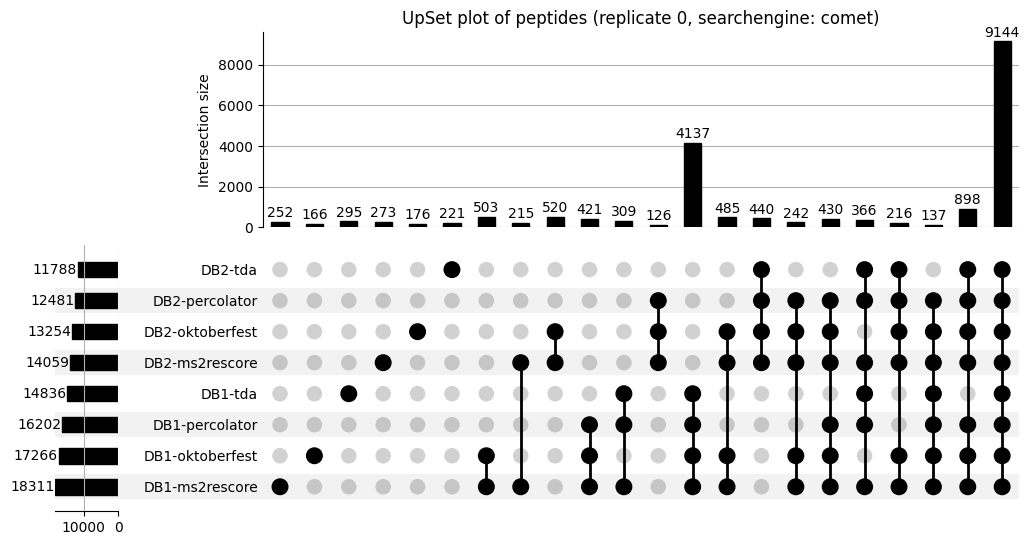

In [15]:
postprocessing = "ms2rescore"  # "tda", "percolator", "ms2rescore"
rep = 0


peprowname = "peptide"
if (postprocessing == "tda"):
    peprowname = "Peptide"

# TODO: put this into the reading in of data...
OKTOBERFEST_MODIFICATION_REPLACEMENTS = [
    ("[UNIMOD:Carbamidomethyl]", "[UNIMOD:4]"),
    ("[UNIMOD:Oxidation]", "[UNIMOD:35]"),
]

def replace_oktoberfest_modifications(sequences):
    return sequences.apply(
        lambda x: x.strip("_")
    ).apply(
        lambda seq: reduce(
            lambda seq_x, repl: seq_x.replace(repl[1], repl[0]), # lambda to replace
            OKTOBERFEST_MODIFICATION_REPLACEMENTS, # replacements
            seq # starting with the sequences as stated in the PSMs file
        )
    )

psm_sets = {}

for db in databases:
    for postprocessing in postprocess_levels:
        if postprocessing == "oktoberfest":
            results[db][searchengine][postprocessing][rep]["peptide"] = replace_oktoberfest_modifications(results[db][searchengine][postprocessing][rep]["peptide"])
        
        peprowname = "peptide"
        if (postprocessing == "tda"):
            peprowname = "Peptide"
        psm_sets[f"{db}-{postprocessing}"] = set(row[peprowname].replace("I", "J").replace("L", "J").replace("UNJMOD", "UNIMOD") for _, row in results[db][searchengine][postprocessing][rep].iterrows())
    

# Build a DataFrame for UpSet plot
upset_data = from_contents(psm_sets)

# Plot the UpSet plot
plt.figure(figsize=(8, 4))
UpSet(upset_data, subset_size='count', show_counts=True, min_subset_size=100).plot()
plt.title(f"UpSet plot of peptides (replicate {rep}, searchengine: {searchengine})")
plt.show()

In [16]:

# Build a DataFrame for UpSet plot
upset_data = from_contents(psm_sets)

# Plot the UpSet plot
plt.figure(figsize=(8, 4))
UpSet(upset_data, min_subset_size='count', show_counts=True, min_degree=50).plot()
plt.title(f"UpSet plot of peptides (replicate {rep}, searchengine: {searchengine}, postprocessing: {postprocessing})")
plt.show()

/home/ubuntu/micromamba/envs/poi-analyses/lib/python3.13/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


ValueError: String value must be formatted as percentage between 0 and 100. Got count

<Figure size 800x400 with 0 Axes>